# Teste do DataPrep Estendido - Todas as Corridas

Este notebook testa o novo sistema de preparação de dados que extrai **TODAS** as corridas dos arquivos CSV da camada bronze (não apenas a última).

## Funcionalidades:
- Lê todos os arquivos CSV da camada bronze
- Detecta e extrai todas as corridas/sweeps de cada arquivo
- Cria DataFrame consolidado com metadados
- Permite filtros fáceis por experimento, pasta, chip, etapa
- Prepara dados prontos para visualização

In [3]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataprep_extended import (
    BronzeDataExtractor,
    ConsolidatedDataAnalyzer,
    create_consolidated_dataframe
)

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 1. Criar DataFrame Consolidado

Vamos criar o DataFrame consolidado com **todos** os dados da camada bronze.

In [4]:
# Criar DataFrame consolidado
print("🚀 Iniciando extração de dados...\n")
df_consolidated = create_consolidated_dataframe(
    base_path="data/bronze/GFETS",
    verbose=True
)

print(f"\n✅ DataFrame consolidado criado com {len(df_consolidated):,} linhas")

🚀 Iniciando extração de dados...

🔍 Encontrados 109 arquivos CSV
📂 C1 - 100pico.csv: 19 corridas detectadas
📂 C1 - 100pico_overTime.csv: 0 corridas detectadas
📂 C1 - 10fento.csv: 19 corridas detectadas
📂 C1 - 10fento_ajustado.csv: 0 corridas detectadas
📂 C1 - 10fento_overTime.csv: 0 corridas detectadas
📂 C1 - 1ato.csv: 19 corridas detectadas
📂 C1 - 1ato_ajustado.csv: 0 corridas detectadas
📂 C1 - 1ato_overTime.csv: 0 corridas detectadas
📂 C1 - APT.csv: 19 corridas detectadas
📂 C1 - APT_ajustado.csv: 0 corridas detectadas
📂 C1 - APT_overTime.csv: 0 corridas detectadas
📂 C1 - BARE.csv: 19 corridas detectadas
📂 C1 - BARE_ajustado.csv: 0 corridas detectadas
📂 C1 - BARE_overTime.csv: 0 corridas detectadas
📂 C1 - BLANK1.csv: 19 corridas detectadas
📂 C1 - BLANK1_ajustado.csv: 0 corridas detectadas
📂 C1 - BLANK1_overTime.csv: 0 corridas detectadas
📂 C1 - BLANK2.csv: 19 corridas detectadas
📂 C1 - BLANK2_ajustado.csv: 0 corridas detectadas
📂 C1 - BLANK2_overTime.csv: 0 corridas detectadas
📂 C1 - 

## 2. Explorar o DataFrame Consolidado

Vamos ver a estrutura dos dados e as colunas de metadados.

In [5]:
# Informações gerais
print("📊 INFORMAÇÕES DO DATAFRAME CONSOLIDADO")
print("="*80)
print(f"Shape: {df_consolidated.shape}")
print(f"\nColunas de metadados:")
metadata_cols = [col for col in df_consolidated.columns if col.startswith('_')]
for col in metadata_cols:
    print(f"  - {col}: {df_consolidated[col].nunique()} valores únicos")

print(f"\n📈 Primeiras linhas:")
df_consolidated.head(3)

📊 INFORMAÇÕES DO DATAFRAME CONSOLIDADO
Shape: (523545, 29)

Colunas de metadados:
  - _timestamp: 1045 valores únicos
  - _sweep_idx: 19 valores únicos
  - _data_experimento: 2 valores únicos
  - _pasta_dados: 2 valores únicos
  - _chip: 5 valores únicos
  - _etapa: 19 valores únicos
  - _arquivo: 50 valores únicos
  - _caminho_relativo: 55 valores únicos

📈 Primeiras linhas:


,Variable Source,dev1,dev2,dev3,dev4,dev5,dev6,dev7,dev8,dev9,...,Dev 19,Dev 20,_timestamp,_sweep_idx,_data_experimento,_pasta_dados,_chip,_etapa,_arquivo,_caminho_relativo
0,"-0,49993858631900023300","0,00000125029044187040","0,00000051770046673295","0,00000007197095580125","0,00000001061211368892","0,00000001113501303215","0,00000123297994427757","0,00000053886687650788","0,00000077977890495703","0,00000000692077961434",...,"0,00000159931748789288","0,00000078831246964228",2025-04-04_18h54m03s,0,03abr,03abr_curves,C1,100pico,C1 - 100pico.csv,03abr/03abr_curves/C1 - 100pico.csv
1,"-0,49793466368168559600","0,00000124920742309555","0,00000051504306628082","0,00000007162640482878","0,00000001056707367306","0,00000001098665939955","0,00000122802129308335","0,00000053624636026850","0,00000077627100737984","0,00000000723115294173",...,"0,00000159155136167000","0,00000078616293530272",2025-04-04_18h54m03s,0,03abr,03abr_curves,C1,100pico,C1 - 100pico.csv,03abr/03abr_curves/C1 - 100pico.csv
2,"-0,49593074104437096000","0,00000124810360315192","0,00000051243190319719","0,00000007128544777956","0,00000001052491472155","0,00000001084935762468","0,00000122305677624284","0,00000053364141171323","0,00000077278371049932","0,00000000752759439672",...,"0,00000158377744407614","0,00000078391613892906",2025-04-04_18h54m03s,0,03abr,03abr_curves,C1,100pico,C1 - 100pico.csv,03abr/03abr_curves/C1 - 100pico.csv


In [6]:
# Ver colunas de dados (não metadados)
data_cols = [col for col in df_consolidated.columns if not col.startswith('_')]
print(f"📊 Colunas de dados ({len(data_cols)} colunas):")
print(data_cols[:10], "..." if len(data_cols) > 10 else "")

📊 Colunas de dados (21 colunas):
['Variable Source', 'dev1', 'dev2', 'dev3', 'dev4', 'dev5', 'dev6', 'dev7', 'dev8', 'dev9'] ...


## 3. Criar Analisador e Explorar Dados

O analisador fornece métodos convenientes para explorar e filtrar os dados.

In [7]:
# Criar analisador
analyzer = ConsolidatedDataAnalyzer(df_consolidated)

print("🔍 DADOS DISPONÍVEIS")
print("="*80)
print(f"\n📅 Experimentos: {analyzer.list_experiments()}")
print(f"\n📁 Pastas: {analyzer.list_folders()}")
print(f"\n💾 Chips: {analyzer.list_chips()}")
print(f"\n📈 Etapas (primeiras 20): {analyzer.list_stages()[:20]}")

🔍 DADOS DISPONÍVEIS

📅 Experimentos: ['03abr', '19abr']

📁 Pastas: ['03abr_curves', '19abr_curves']

💾 Chips: ['C1', 'C2', 'C3', 'C4', 'C5']

📈 Etapas (primeiras 20): ['100fento', '100pico', '10fento', '185pico', '1ato', '1fento', '1pico', '370pico', '556pico', '741pico', 'APT', 'BARE', 'BLANK1', 'BLANK2', 'BLANK3', 'DDT', 'ETA', 'ETOH', 'PBSE']


## 4. Exemplo: Filtrar dados do experimento 19abr

Vamos filtrar dados de um experimento específico.

In [8]:
# Filtrar por experimento
experimento = "19abr"
pasta = "19abr_curves"

df_19abr = analyzer.filter_data(
    experiment=experimento,
    folder=pasta
)

print(f"📊 Dados de {experimento}/{pasta}")
print("="*80)
print(f"Total de linhas: {len(df_19abr):,}")
print(f"\nChips disponíveis: {sorted(df_19abr['_chip'].unique())}")
print(f"\nEtapas disponíveis (primeiras 15): {sorted(df_19abr['_etapa'].unique())[:15]}")
print(f"\nNúmero de corridas por arquivo:")
sweeps_por_arquivo = df_19abr.groupby('_arquivo')['_sweep_idx'].nunique().sort_index()
print(sweeps_por_arquivo.head(10))

📊 Dados de 19abr/19abr_curves
Total de linhas: 295,089

Chips disponíveis: ['C1', 'C2', 'C3', 'C4', 'C5']

Etapas disponíveis (primeiras 15): ['100fento', '100pico', '185pico', '1ato', '1fento', '1pico', '370pico', '556pico', '741pico', 'APT', 'BARE', 'BLANK1', 'BLANK2', 'BLANK3', 'DDT']

Número de corridas por arquivo:
_arquivo
C1 - 185pico.csv     19
C1 - 1ato.csv        19
C1 - 1fento.csv      19
C1 - 1pico.csv       19
C2 - BLANK3.csv      19
C2 - DDT.csv         19
C2 - ETA.csv         19
C2 - PBSE.csv        19
C3 - 100fento.csv    19
C3 - 100pico.csv     19
Name: _sweep_idx, dtype: int64


## 5. Exemplo: Filtrar dados do chip C1

Agora vamos filtrar especificamente os dados do chip C1.

In [9]:
# Filtrar por chip
chip = "C1"

df_c1 = analyzer.filter_data(
    experiment=experimento,
    folder=pasta,
    chip=chip
)

print(f"📊 Dados de {experimento}/{pasta} - Chip {chip}")
print("="*80)
print(f"Total de linhas: {len(df_c1):,}")
print(f"\nEtapas disponíveis para {chip}:")
etapas_c1 = sorted(df_c1['_etapa'].unique())
print(etapas_c1)

📊 Dados de 19abr/19abr_curves - Chip C1
Total de linhas: 38,076

Etapas disponíveis para C1:
['185pico', '1ato', '1fento', '1pico']


## 6. Exemplo: Obter dados específicos (1ato, 1fento, 1pico)

Vamos filtrar as etapas específicas mencionadas: 1ato, 1fento, 1pico

In [10]:
# Filtrar etapas específicas
etapas_interesse = ["1ato", "1fento", "1pico"]

print(f"📊 Filtrando etapas: {etapas_interesse}")
print("="*80)

for etapa in etapas_interesse:
    df_etapa = analyzer.filter_data(
        experiment=experimento,
        folder=pasta,
        chip=chip,
        stage=etapa
    )
    
    if len(df_etapa) > 0:
        num_sweeps = df_etapa['_sweep_idx'].nunique()
        print(f"\n✅ {etapa}:")
        print(f"   - Total de linhas: {len(df_etapa):,}")
        print(f"   - Número de corridas: {num_sweeps}")
        print(f"   - Corridas disponíveis: {sorted(df_etapa['_sweep_idx'].unique())}")
    else:
        print(f"\n⚠️ {etapa}: não encontrado")

📊 Filtrando etapas: ['1ato', '1fento', '1pico']

✅ 1ato:
   - Total de linhas: 9,519
   - Número de corridas: 19
   - Corridas disponíveis: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

✅ 1fento:
   - Total de linhas: 9,519
   - Número de corridas: 19
   - Corridas disponíveis: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]

✅ 1pico:
   - Total de linhas: 9,519
   - Número de corridas: 19
   - Corridas disponíveis: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


## 6.5. DEBUG: Ler Arquivo CSV Diretamente

Primeiro, vamos ler um arquivo CSV diretamente para entender sua estrutura.

In [11]:
# DEBUG: Ler um arquivo CSV diretamente
import pandas as pd

# Ler arquivo bruto
arquivo_teste = "data/bronze/GFETS/19abr/19abr_curves/C1 - 1ato.csv"

print(f"🔍 Lendo arquivo: {arquivo_teste}")
print("="*80)

# Ler com skiprows=16 como no código
df_raw = pd.read_csv(arquivo_teste, sep=";", skiprows=16, header=None, nrows=50)

print(f"\n📊 Shape: {df_raw.shape}")
print(f"\n📋 Primeiras 20 linhas:")
print(df_raw.head(20))

print(f"\n📋 Colunas: {df_raw.columns.tolist()}")

# Procurar por linhas com timestamp
import re
timestamp_pattern = re.compile(r'^\d{4}-\d{2}-\d{2}_\d{2}h\d{2}m\d{2}s')

print(f"\n🕐 Procurando timestamps...")
for idx, row in df_raw.head(20).iterrows():
    first_val = str(row.iloc[0])
    if timestamp_pattern.match(first_val):
        print(f"  Linha {idx}: {first_val[:50]}")
        print(f"  Próxima linha (header): {df_raw.iloc[idx+1, 0]}")

🔍 Lendo arquivo: data/bronze/GFETS/19abr/19abr_curves/C1 - 1ato.csv

📊 Shape: (50, 21)

📋 Primeiras 20 linhas:
                         0                       1                       2   \
0           Variable Source                    dev1                    dev2   
1   -0,49998722875999979100  0,00000023780293189138  0,00000161366582396796   
2   -0,49798330325792361500  0,00000023798199378407  0,00000161055523968217   
3   -0,49597937775584749500  0,00000023812628926093  0,00000160744215971767   
4   -0,49397545225377131900  0,00000023823581832196  0,00000160432658407447   
5   -0,49197152675169519800  0,00000023831058096717  0,00000160120851275255   
6   -0,48996760124961902200  0,00000023835057719655  0,00000159808794575193   
7   -0,48796367574754284600  0,00000023835580701011  0,00000159496488307260   
8   -0,48595975024546672600  0,00000023832627040783  0,00000159183932471456   
9   -0,48395582474339055000  0,00000023826196738973  0,00000158871127067781   
10  -0,4819518992413

## 6.6. DEBUG: Inspecionar Dados Consolidados

Agora vamos verificar o que foi extraído no DataFrame consolidado.

In [12]:
# DEBUG: Ver colunas disponíveis e dados brutos
print("🔍 DEBUG: Verificando estrutura dos dados")
print("="*80)

# Pegar dados de uma etapa específica
df_debug = analyzer.filter_data(
    experiment=experimento,
    folder=pasta,
    chip=chip,
    stage="1ato"
)

if len(df_debug) > 0:
    print(f"\n📊 Dados encontrados para 1ato: {len(df_debug)} linhas")
    print(f"\n📋 Colunas disponíveis ({len(df_debug.columns)} colunas):")
    print(df_debug.columns.tolist()[:30])  # Primeiras 30 colunas
    
    print(f"\n📋 Primeiras linhas dos dados:")
    print(df_debug.head(3))
    
    print(f"\n🔢 Valores únicos de _sweep_idx: {sorted(df_debug['_sweep_idx'].unique())}")
    
    # Verificar se as colunas esperadas existem
    print(f"\n✓ 'Variable Source' existe? {'Variable Source' in df_debug.columns}")
    print(f"✓ 'dev1' existe? {'dev1' in df_debug.columns}")
    
    # Ver algumas linhas de dados de uma corrida específica
    if len(df_debug) > 0:
        sweep_num = df_debug['_sweep_idx'].max()
        df_one_sweep = df_debug[df_debug['_sweep_idx'] == sweep_num]
        print(f"\n📈 Dados da última corrida (sweep {sweep_num}): {len(df_one_sweep)} linhas")
        
        # Tentar encontrar colunas que parecem ser de voltagem
        voltage_cols = [col for col in df_debug.columns if 'var' in col.lower() or 'volt' in col.lower() or 'source' in col.lower()]
        print(f"\n⚡ Colunas que podem ser de voltagem: {voltage_cols[:10]}")
        
        # Tentar encontrar colunas que parecem ser de dados (dev)
        dev_cols = [col for col in df_debug.columns if 'dev' in col.lower()]
        print(f"\n📡 Colunas device encontradas: {dev_cols[:10]}")
else:
    print("\n⚠️ Nenhum dado encontrado para debug!")

🔍 DEBUG: Verificando estrutura dos dados

📊 Dados encontrados para 1ato: 9519 linhas

📋 Colunas disponíveis (29 colunas):
['Variable Source', 'dev1', 'dev2', 'dev3', 'dev4', 'dev5', 'dev6', 'dev7', 'dev8', 'dev9', 'dev10', 'dev11', 'dev12', 'dev13', 'dev14', 'dev15', 'dev16', 'dev17', 'Dev 18', 'Dev 19', 'Dev 20', '_timestamp', '_sweep_idx', '_data_experimento', '_pasta_dados', '_chip', '_etapa', '_arquivo', '_caminho_relativo']

📋 Primeiras linhas dos dados:
                Variable Source                    dev1  \
237975  -0,49998722875999979100  0,00000024047515337818   
237976  -0,49798330325792361500  0,00000024051568650929   
237977  -0,49597937775584749500  0,00000024053210542821   

                          dev2                    dev3  \
237975  0,00000161574079537439  0,00000126331759573821   
237976  0,00000161282797399176  0,00000126038081789401   
237977  0,00000160989268585130  0,00000125743176206127   

                          dev4                    dev5  \
237975  

## 6.7. Teste de Conversão de Formato Decimal

O problema foi identificado: os dados usam vírgula como separador decimal (formato europeu). Vamos testar a conversão antes de usar o método get_plot_data.

In [13]:
# Teste de conversão manual
print("🧪 TESTE: Conversão de formato decimal")
print("="*80)

# Pegar uma amostra pequena
df_teste = analyzer.filter_data(
    experiment=experimento,
    folder=pasta,
    chip=chip,
    stage="1ato",
    sweep_idx=18  # última corrida
)

if len(df_teste) > 0:
    print(f"\n📊 Dados originais (primeiras 3 linhas):")
    print(df_teste[['Variable Source', 'dev1']].head(3))
    
    # Testar conversão
    df_conv = df_teste[['Variable Source', 'dev1']].copy()
    
    # Converter vírgulas para pontos
    df_conv['Variable Source'] = df_conv['Variable Source'].astype(str).str.replace(',', '.')
    df_conv['dev1'] = df_conv['dev1'].astype(str).str.replace(',', '.')
    
    # Converter para numérico
    df_conv['Variable Source'] = pd.to_numeric(df_conv['Variable Source'], errors='coerce')
    df_conv['dev1'] = pd.to_numeric(df_conv['dev1'], errors='coerce')
    
    # Remover NaN
    df_conv = df_conv.dropna()
    
    print(f"\n✅ Dados convertidos (primeiras 3 linhas):")
    print(df_conv.head(3))
    
    print(f"\n📈 Shape após conversão: {df_conv.shape}")
    print(f"✅ Conversão bem-sucedida! {len(df_conv)} linhas convertidas.")
else:
    print("⚠️ Nenhum dado para teste")

🧪 TESTE: Conversão de formato decimal

📊 Dados originais (primeiras 3 linhas):
                Variable Source                    dev1
246993  -0,49998722875999979100  0,00000024626234865057
246994  -0,49798330325792361500  0,00000024613209556339
246995  -0,49597937775584749500  0,00000024598514191964

✅ Dados convertidos (primeiras 3 linhas):
        Variable Source          dev1
246993        -0.499987  2.462623e-07
246994        -0.497983  2.461321e-07
246995        -0.495979  2.459851e-07

📈 Shape após conversão: (500, 2)
✅ Conversão bem-sucedida! 500 linhas convertidas.


## 7. Preparar Dados para Plotagem (CORRIGIDO)

⚠️ **IMPORTANTE**: Antes de executar, reinicie o kernel ou recarregue o módulo `dataprep_extended` para usar a versão corrigida!

Vamos usar o método `get_plot_data` (agora corrigido para lidar com vírgulas decimais) para obter dados prontos para plotagem.

In [14]:
# IMPORTANTE: Recarregar o módulo para pegar a versão corrigida
import importlib
import dataprep_extended
importlib.reload(dataprep_extended)
from dataprep_extended import ConsolidatedDataAnalyzer

# Recriar o analyzer com o módulo atualizado  
analyzer = ConsolidatedDataAnalyzer(df_consolidated)

print("✅ Módulo dataprep_extended recarregado com a correção!")

✅ Módulo dataprep_extended recarregado com a correção!


In [15]:
# Obter dados para plot
etapas_plot = ["1ato", "1fento", "1pico"]

plot_data = analyzer.get_plot_data(
    experiment=experimento,
    folder=pasta,
    chip=chip,
    stages=etapas_plot,
    x_col="Variable Source",
    y_col="dev1",
    sweep_idx=-1  # -1 para pegar última corrida
)

print(f"📈 Dados preparados para plotagem:")
print("="*80)
for etapa, df_plot in plot_data.items():
    print(f"\n{etapa}:")
    print(f"  - Shape: {df_plot.shape}")
    print(f"  - Colunas: {df_plot.columns.tolist()}")
    print(f"  - Range X: [{df_plot.iloc[:, 0].min():.3f}, {df_plot.iloc[:, 0].max():.3f}]")
    print(f"  - Range Y: [{df_plot.iloc[:, 1].min():.2e}, {df_plot.iloc[:, 1].max():.2e}]")

📈 Dados preparados para plotagem:

1ato:
  - Shape: (500, 2)
  - Colunas: ['Variable Source', 'dev1']
  - Range X: [-0.500, 0.500]
  - Range Y: [8.45e-08, 2.46e-07]

1fento:
  - Shape: (500, 2)
  - Colunas: ['Variable Source', 'dev1']
  - Range X: [-0.500, 0.500]
  - Range Y: [8.18e-08, 2.30e-07]

1pico:
  - Shape: (500, 2)
  - Colunas: ['Variable Source', 'dev1']
  - Range X: [-0.500, 0.500]
  - Range Y: [8.09e-08, 2.37e-07]


## 8. Exemplo de Visualização

Vamos criar um plot simples com os dados preparados.

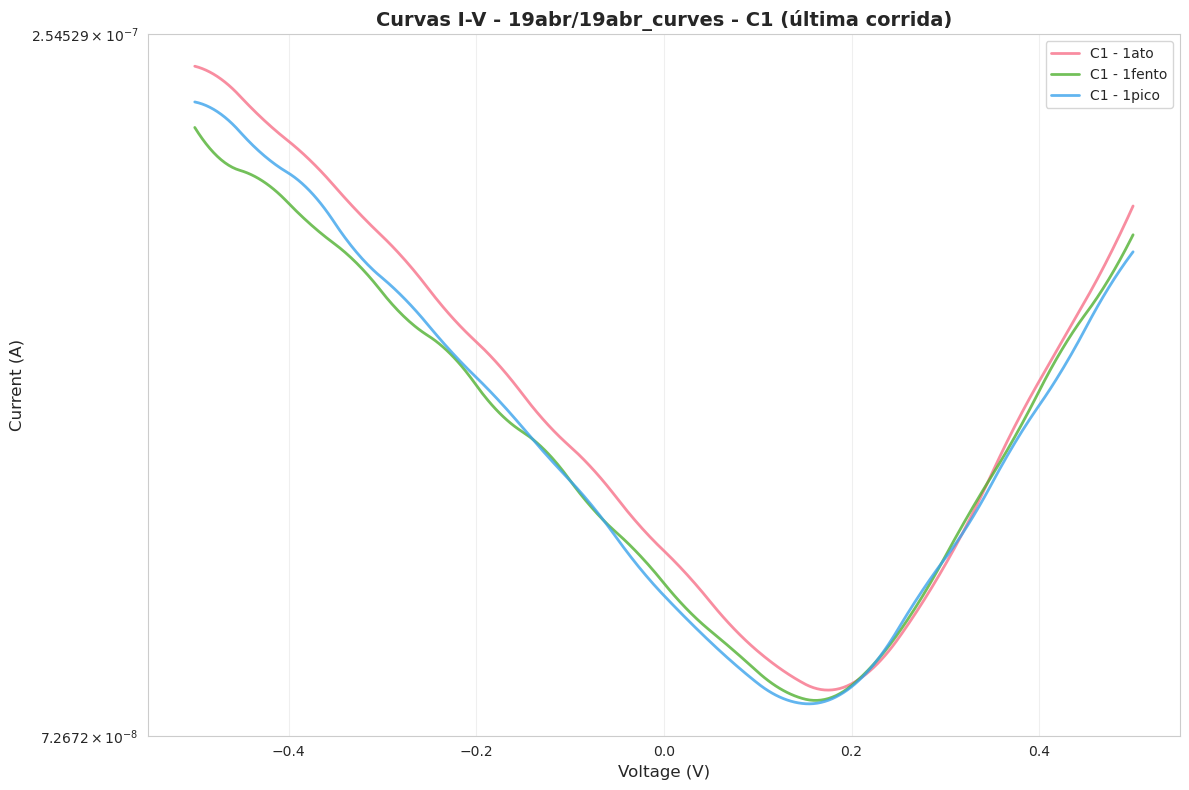

✅ Plot criado com sucesso!


In [16]:
# Plot simples
fig, ax = plt.subplots(figsize=(12, 8))

colors = sns.color_palette('husl', len(plot_data))

for idx, (etapa, df_plot) in enumerate(plot_data.items()):
    x_col = df_plot.columns[0]
    y_col = df_plot.columns[1]
    
    ax.plot(df_plot[x_col], df_plot[y_col], 
            label=f'{chip} - {etapa}',
            linewidth=2,
            alpha=0.8,
            color=colors[idx])

ax.set_xlabel('Voltage (V)', fontsize=12)
ax.set_ylabel('Current (A)', fontsize=12)
ax.set_title(f'Curvas I-V - {experimento}/{pasta} - {chip} (última corrida)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_yscale('symlog')

plt.tight_layout()
plt.show()

print("✅ Plot criado com sucesso!")

## 9. Comparar Diferentes Corridas

Como agora temos todas as corridas, podemos comparar múltiplas corridas do mesmo arquivo.

📊 Corridas disponíveis para C1 - 1ato: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Total: 19 corridas



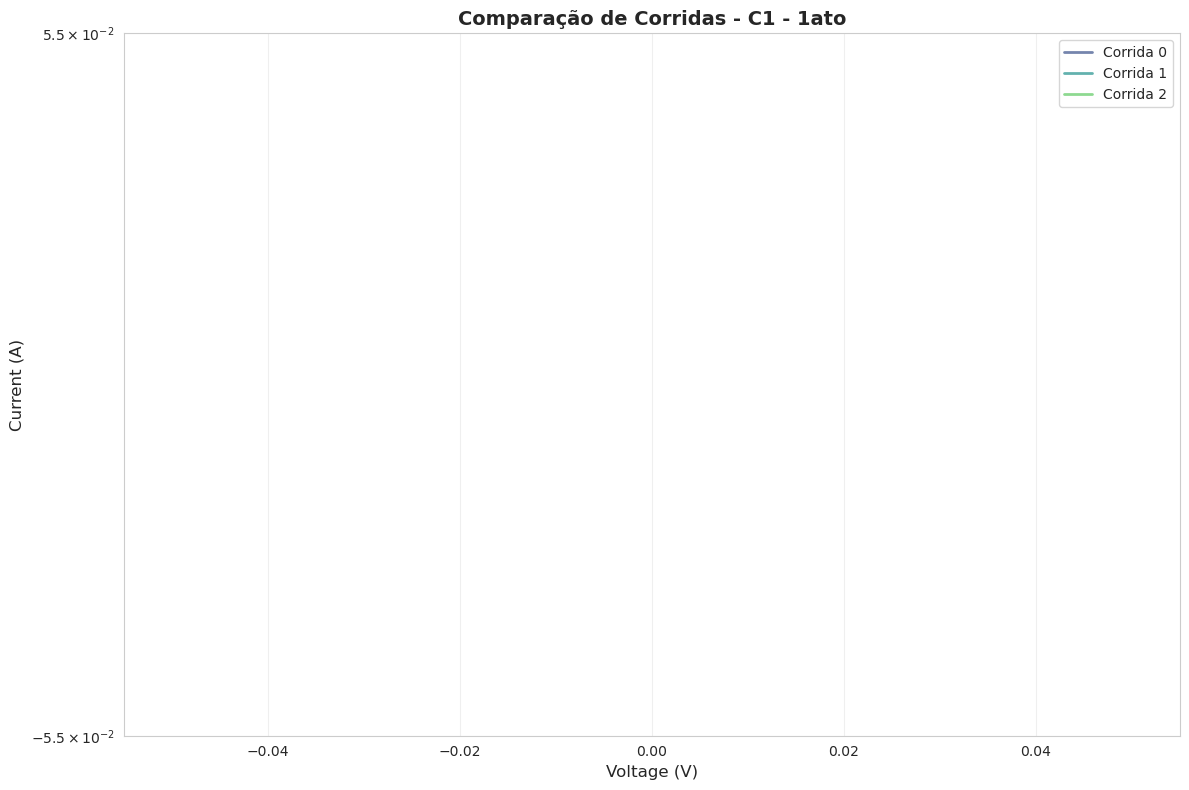

✅ Comparação de corridas criada!


In [17]:
# Comparar corridas de um mesmo arquivo
etapa_comparar = "1ato"  # Escolher uma etapa

df_todas_corridas = analyzer.filter_data(
    experiment=experimento,
    folder=pasta,
    chip=chip,
    stage=etapa_comparar
)

if len(df_todas_corridas) > 0:
    sweeps_disponiveis = sorted(df_todas_corridas['_sweep_idx'].unique())
    print(f"📊 Corridas disponíveis para {chip} - {etapa_comparar}: {sweeps_disponiveis}")
    print(f"Total: {len(sweeps_disponiveis)} corridas\n")
    
    # Plot comparando primeiras 3 corridas
    fig, ax = plt.subplots(figsize=(12, 8))
    
    num_corridas_plot = min(3, len(sweeps_disponiveis))
    colors = sns.color_palette('viridis', num_corridas_plot)
    
    for idx, sweep_idx in enumerate(sweeps_disponiveis[:num_corridas_plot]):
        df_sweep = df_todas_corridas[df_todas_corridas['_sweep_idx'] == sweep_idx]
        
        # Preparar dados
        x = pd.to_numeric(df_sweep['Variable Source'], errors='coerce')
        y = pd.to_numeric(df_sweep['dev1'], errors='coerce')
        
        # Remover NaN
        mask = ~(x.isna() | y.isna())
        x = x[mask]
        y = y[mask]
        
        ax.plot(x, y, 
                label=f'Corrida {sweep_idx}',
                linewidth=2,
                alpha=0.7,
                color=colors[idx])
    
    ax.set_xlabel('Voltage (V)', fontsize=12)
    ax.set_ylabel('Current (A)', fontsize=12)
    ax.set_title(f'Comparação de Corridas - {chip} - {etapa_comparar}', 
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('symlog')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Comparação de corridas criada!")
else:
    print(f"⚠️ Nenhum dado encontrado para {chip} - {etapa_comparar}")

## 10. Salvar DataFrame Consolidado

Vamos salvar o DataFrame consolidado para uso futuro.

In [18]:
#pip install pyarrow

In [20]:
# Salvar DataFrame consolidado

# Tentar salvar em formato Parquet (mais eficiente)
try:
    analyzer.save_consolidated("data/gold/consolidated_all_data.parquet")
    parquet_saved = True
except ImportError as e:
    print(f"⚠️ Não foi possível salvar em Parquet: pyarrow não está instalado")
    print(f"   Para instalar: pip install pyarrow")
    parquet_saved = False

# Salvar em CSV (sempre funciona)
analyzer.save_consolidated("data/gold/consolidated_all_data.csv")

print("\n✅ Salvamento concluído!")
if parquet_saved:
    print("   ✓ data/gold/consolidated_all_data.parquet")
print("   ✓ data/gold/consolidated_all_data.csv")

⚠️ Não foi possível salvar em Parquet: pyarrow não está instalado
   Para instalar: pip install pyarrow
✅ Dados salvos em: data/gold/consolidated_all_data.csv (formato CSV)

✅ Salvamento concluído!
   ✓ data/gold/consolidated_all_data.csv


## 11. Resumo das Funcionalidades

### Principais Vantagens do Novo Sistema:

1. **Todas as Corridas**: Não perde mais dados! Extrai todas as corridas de cada arquivo.

2. **Metadados Completos**: Cada linha tem informações sobre:
   - `_data_experimento`: Data do experimento (ex: 19abr)
   - `_pasta_dados`: Pasta dos dados (ex: 19abr_curves)
   - `_chip`: Chip (ex: C1, C2, C3)
   - `_etapa`: Etapa do experimento (ex: 1ato, 1fento, BARE)
   - `_sweep_idx`: Índice da corrida (0, 1, 2, ...)
   - `_timestamp`: Timestamp da corrida

3. **Filtros Fáceis**: Use o `ConsolidatedDataAnalyzer` para filtrar dados facilmente:
   ```python
   # Filtrar por experimento
   df = analyzer.filter_data(experiment="19abr")
   
   # Filtrar por chip
   df = analyzer.filter_data(experiment="19abr", chip="C1")
   
   # Filtrar etapas específicas
   df = analyzer.filter_data(chip="C1", stage="1ato")
   ```

4. **Dados Prontos para Plot**: Use `get_plot_data()` para obter dados já preparados:
   ```python
   plot_data = analyzer.get_plot_data(
       experiment="19abr",
       folder="19abr_curves",
       chip="C1",
       stages=["1ato", "1fento"],
       sweep_idx=-1  # última corrida
   )
   ```

5. **Comparar Corridas**: Agora é possível comparar diferentes corridas do mesmo arquivo para análise de reprodutibilidade.

6. **Formatos Eficientes**: Salve em Parquet (rápido e compacto) ou CSV (compatível).

## 💡 App Streamlit Interativo

### 🚀 Sistema de Visualização Interativa Disponível!

Criamos um **app Streamlit completo** que permite montar visualizações interativamente! 

#### 📊 Funcionalidades do App:

1. **📈 Comparar Etapas**: Compare diferentes etapas do mesmo chip
2. **🔄 Comparar Corridas**: Compare múltiplas corridas da mesma etapa
3. **📊 Visualização Custom**: Controle total sobre o que plotar
4. **📈 Análise de Reprodutibilidade**: Calcule CV entre corridas
5. **💾 Download de Dados**: Exporte dados filtrados

#### 🎯 Como executar:

```bash
# Opção 1: Usar o script
./run_streamlit.sh

# Opção 2: Comando direto
streamlit run streamlit_app_extended.py
```

O app será aberto em: **http://localhost:8501**

#### ✨ Exemplo de uso:

No app, você pode:
- Selecionar **Experimento**: 19abr
- Selecionar **Chip**: C1  
- Na aba **"Comparar Corridas"**: 
  - Escolher etapa: 1ato
  - Selecionar múltiplas corridas (ex: 0, 5, 10, 15, 18)
  - Ver a comparação visual e análise de reprodutibilidade!

#### 📸 O que você pode fazer:

- ✅ Ver todas as etapas disponíveis por chip
- ✅ Comparar qualquer combinação de etapas
- ✅ Analisar reprodutibilidade entre corridas
- ✅ Escolher qualquer device (dev1, dev2, etc.)
- ✅ Alternar entre escala linear/logarítmica
- ✅ Download dos dados filtrados em CSV

## 🔧 Instalação e Requisitos

Se você ainda não tem o Streamlit instalado:

```bash
pip install streamlit
```

Todos os outros requisitos já estão instalados (pandas, matplotlib, seaborn, numpy).

## 📝 Próximos Desenvolvimentos

Possíveis melhorias futuras:
- Detecção automática de outliers
- Análises estatísticas avançadas (ANOVA entre corridas)
- Comparações entre diferentes chips
- Relatórios automatizados em PDF
- Machine learning para classificação de curvas